# 02 — Cleaning & EDA

Inputs: `../data/grab_reviews_raw.csv`  
Outputs: `../data/grab_reviews_clean.csv`

Steps:
1. Load raw data
2. Drop duplicates and nulls
3. Detect and keep English-only reviews
4. Clean text (strip HTML, normalise whitespace)
5. Create `sentiment` label from star ratings (1-2 → negative, 3 → neutral, 4-5 → positive)
6. EDA: rating distribution, review volume over time, word clouds by rating

In [2]:
import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from langdetect import detect, LangDetectException
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
tqdm.pandas()
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/grab_reviews_raw.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} reviews')
df.info()

Loaded 10,000 reviews
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_text  10000 non-null  object        
 1   rating       10000 non-null  int64         
 2   date         10000 non-null  datetime64[ns]
 3   author       10000 non-null  object        
 4   source       10000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 390.8+ KB


## 1. Remove Duplicates & Nulls

In [3]:
before = len(df)
df = df.drop_duplicates(subset=['review_text'])
df = df.dropna(subset=['review_text', 'rating'])
df['review_text'] = df['review_text'].astype(str).str.strip()
df = df[df['review_text'].str.len() > 5]   # drop near-empty reviews
print(f'Dropped {before - len(df):,} rows → {len(df):,} remaining')

Dropped 1,802 rows → 8,198 remaining


## 2. Text Cleaning

In [4]:
def clean_text(text: str) -> str:
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)    # remove non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()       # normalise whitespace
    return text

df['review_clean'] = df['review_text'].progress_apply(clean_text)
df.head(3)[['review_text', 'review_clean']]

  0%|          | 0/8198 [00:00<?, ?it/s]

,review_text,review_clean
0,excellent service in Bali,excellent service in Bali
1,uang saya dipotong untuk perjalanan yang tidak...,uang saya dipotong untuk perjalanan yang tidak...
2,"Got scam by the app, put in an order waited ov...","Got scam by the app, put in an order waited ov..."


## 3. Language Detection (keep English only)

In [5]:
def detect_lang(text: str) -> str:
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

df['lang'] = df['review_clean'].progress_apply(detect_lang)
print(df['lang'].value_counts().head(10))

before = len(df)
df = df[df['lang'] == 'en'].copy()
print(f'Dropped {before - len(df):,} non-English rows → {len(df):,} remaining')

  0%|          | 0/8198 [00:00<?, ?it/s]

lang
en         5333
id         1184
tl          356
af          141
unknown     113
da          110
fr          103
vi          102
so          101
it           84
Name: count, dtype: int64
Dropped 2,865 non-English rows → 5,333 remaining


## 4. Sentiment Labels from Star Ratings

In [6]:
def star_to_sentiment(star: int) -> str:
    if star <= 2:
        return 'negative'
    elif star == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].astype(int).apply(star_to_sentiment)
df['sentiment_id'] = df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

print(df['sentiment'].value_counts())

sentiment
negative    2724
positive    2372
neutral      237
Name: count, dtype: int64


## 5. EDA — Rating Distribution

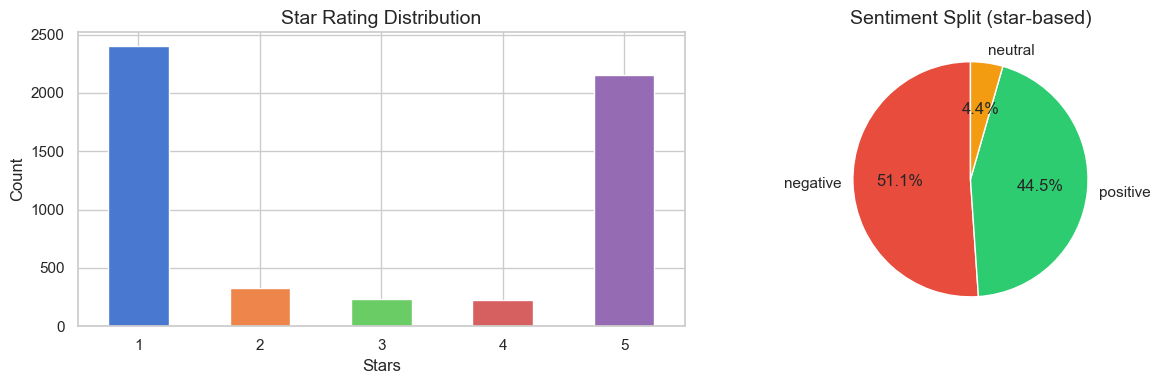

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Star distribution
df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=sns.color_palette('muted'), edgecolor='white'
)
axes[0].set_title('Star Rating Distribution', fontsize=14)
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Sentiment split
sentiment_counts = df['sentiment'].value_counts()
colors = {'negative': '#e74c3c', 'neutral': '#f39c12', 'positive': '#2ecc71'}
sentiment_counts.plot(
    kind='pie', ax=axes[1],
    colors=[colors[s] for s in sentiment_counts.index],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Sentiment Split (star-based)', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/02_rating_dist.png', dpi=120)
plt.show()

## 6. EDA — Review Volume Over Time

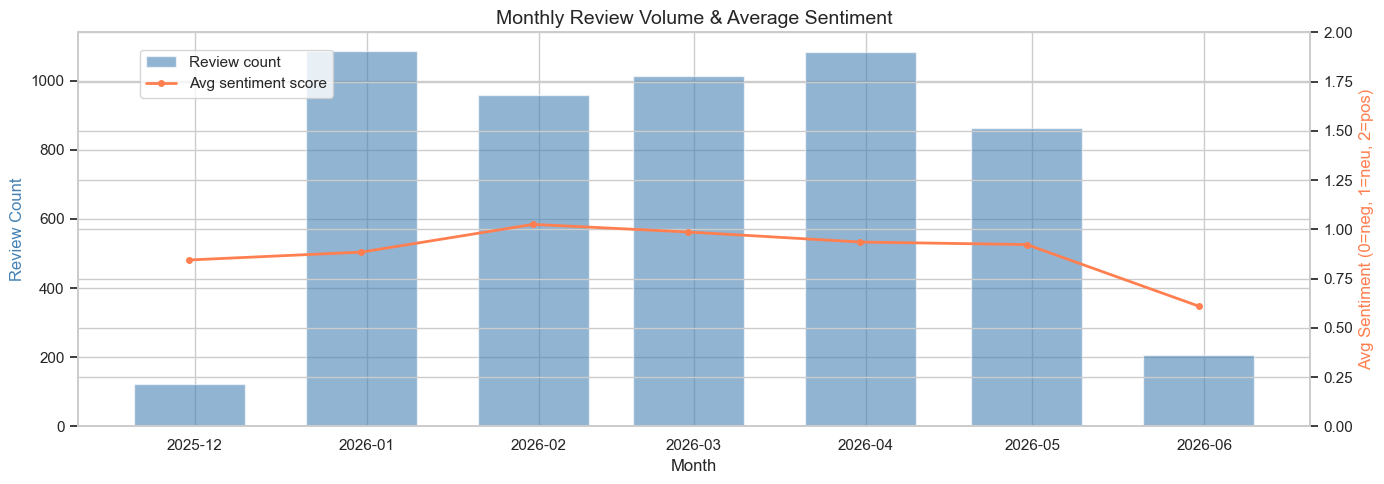

In [8]:
df_ts = df.set_index('date').resample('ME')[['sentiment_id']].agg(
    count=('sentiment_id', 'count'),
    avg_rating=('sentiment_id', 'mean'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(df_ts['date'], df_ts['count'], width=20, color='steelblue', alpha=0.6, label='Review count')
ax1.set_ylabel('Review Count', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_ts['date'], df_ts['avg_rating'], color='coral', lw=2, marker='o', ms=4, label='Avg sentiment score')
ax2.set_ylabel('Avg Sentiment (0=neg, 1=neu, 2=pos)', color='coral')
ax2.set_ylim(0, 2)

ax1.set_title('Monthly Review Volume & Average Sentiment', fontsize=14)
ax1.set_xlabel('Month')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('../data/02_volume_over_time.png', dpi=120)
plt.show()

## 7. EDA — Word Clouds by Rating

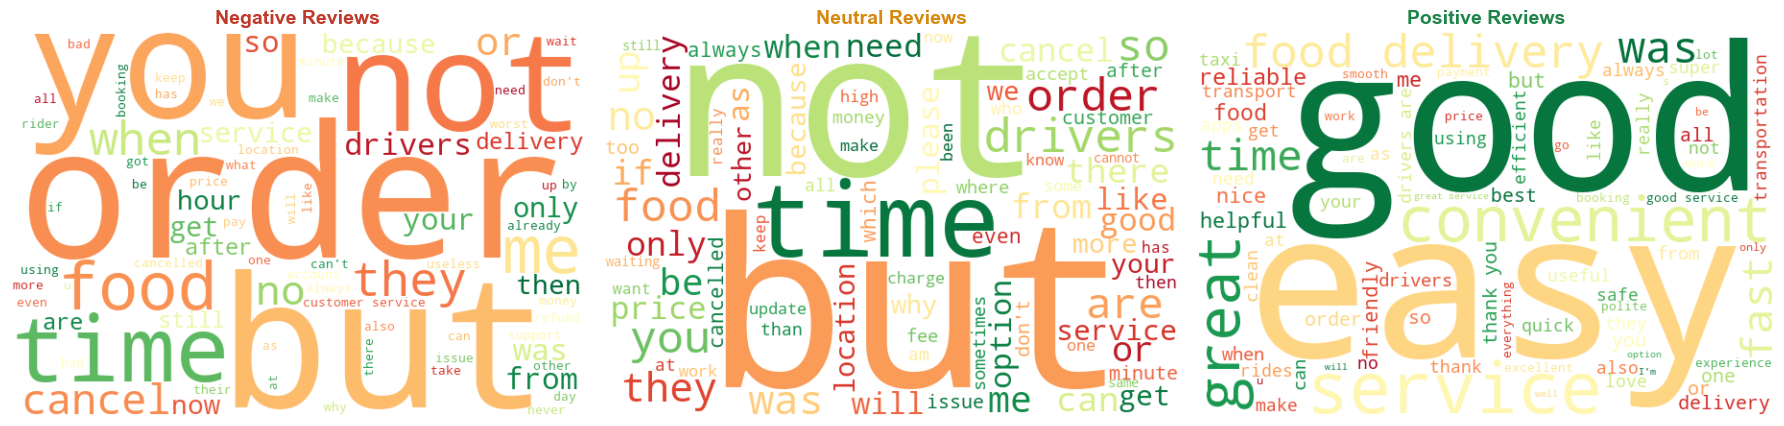

In [9]:
STOPWORDS = {
    'grab', 'app', 'uber', 'driver', 'ride', 'car', 'use', 'used',
    'the', 'a', 'an', 'is', 'it', 'i', 'my', 'this', 'that', 'and',
    'to', 'of', 'in', 'for', 'on', 'with', 'have', 'very', 'just',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = [('negative', '#c0392b'), ('neutral', '#d68910'), ('positive', '#1e8449')]

for ax, (sent, color) in zip(axes, sentiments):
    corpus = ' '.join(df[df['sentiment'] == sent]['review_clean'])
    wc = WordCloud(
        width=600, height=400, background_color='white',
        colormap='RdYlGn', stopwords=STOPWORDS, max_words=80
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sent.capitalize()} Reviews', fontsize=14, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/02_wordclouds.png', dpi=120)
plt.show()

## 8. Save Cleaned Data

In [10]:
OUT = '../data/grab_reviews_clean.csv'
df.to_csv(OUT, index=False)
print(f'Saved {len(df):,} clean rows to {OUT}')
df[['review_clean', 'rating', 'sentiment', 'date', 'source']].head()

Saved 5,333 clean rows to ../data/grab_reviews_clean.csv


,review_clean,rating,sentiment,date,source
2,"Got scam by the app, put in an order waited ov...",1,negative,2026-05-08 21:53:20,google_play
4,The app is well designed and easy to use . How...,5,positive,2026-05-08 21:17:31,google_play
6,DO NOT pay with debit card. This app NEVER ref...,1,negative,2026-05-08 21:13:24,google_play
8,Great app in many regards. But please can you ...,5,positive,2026-05-08 20:59:34,google_play
9,convenient and user friendly.,5,positive,2026-05-08 20:59:14,google_play
